# Start


## Suplementary


In [5]:
pip install pandas matplotlib seaborn numpy

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------  8.1/8.3 MB 44.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 38.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 29.9 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the CSV files
fb_df = pd.read_csv('fb_stock_prices_2018.csv', parse_dates=['date'], index_col='date')
earthquakes_df = pd.read_csv('earthquakes-1.csv')

### 1. Plot the rolling 20-day minimum of the Facebook closing price with the pandas plot() method.

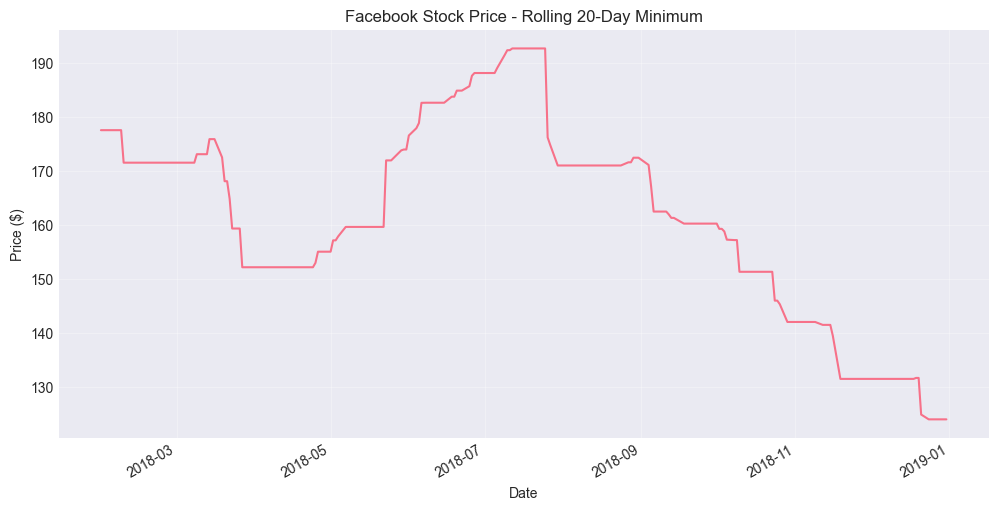

In [8]:
# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

plt.figure(figsize=(12, 6))
fb_df['close'].rolling(window=20).min().plot()
plt.title('Facebook Stock Price - Rolling 20-Day Minimum')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)
plt.show()

### 2. Create a histogram and KDE of the change from open to close in the price of Facebook stock.

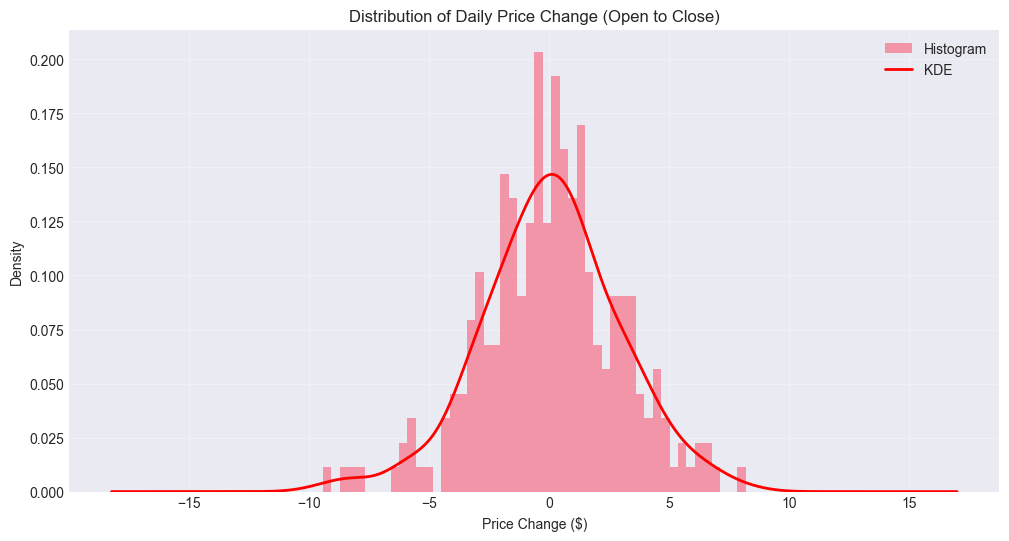

In [9]:
plt.figure(figsize=(12, 6))
fb_df['open_to_close'] = fb_df['close'] - fb_df['open']

fb_df['open_to_close'].plot(kind='hist', bins=50, density=True, alpha=0.7, 
                            label='Histogram')
fb_df['open_to_close'].plot(kind='kde', label='KDE', color='red', linewidth=2)

plt.title('Distribution of Daily Price Change (Open to Close)')
plt.xlabel('Price Change ($)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3. Using the earthquake data, create box plots for the magnitudes of each magType used in Indonesia.

<Figure size 1000x600 with 0 Axes>

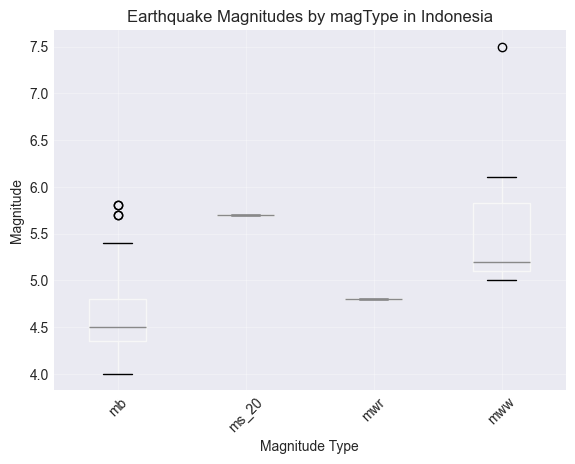

In [10]:
indonesia_eq = earthquakes_df[earthquakes_df['parsed_place'] == 'Indonesia']
plt.figure(figsize=(10, 6))
indonesia_eq.boxplot(column='mag', by='magType')
plt.title('Earthquake Magnitudes by magType in Indonesia')
plt.suptitle('')  # Remove the automatic suptitle
plt.xlabel('Magnitude Type')
plt.ylabel('Magnitude')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

### 4. Make a line plot of the difference between the weekly maximum high price and the weekly minimum low price for Facebook. This should be a single line.

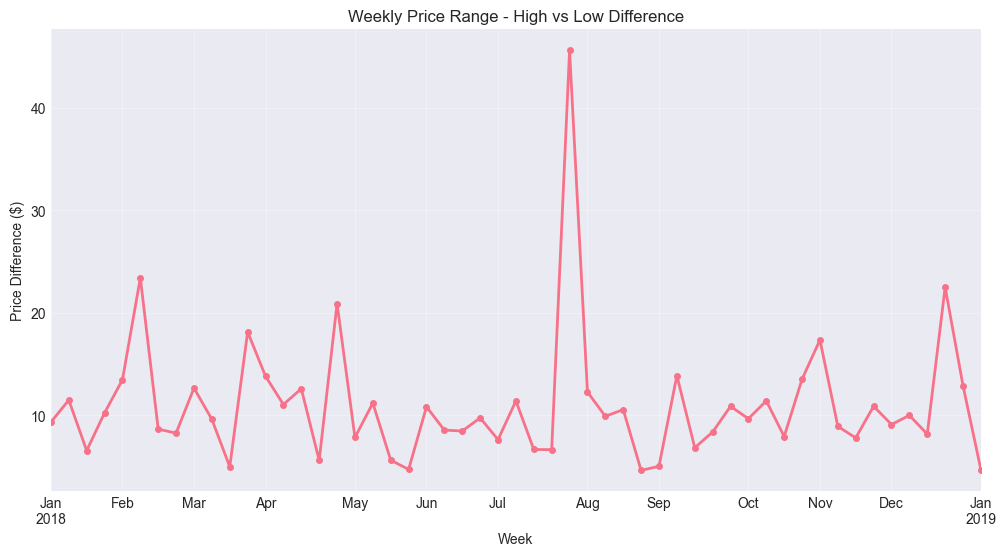

In [11]:
weekly_high = fb_df['high'].resample('W').max()
weekly_low = fb_df['low'].resample('W').min()
weekly_diff = weekly_high - weekly_low

plt.figure(figsize=(12, 6))
weekly_diff.plot(marker='o', linewidth=2, markersize=4)
plt.title('Weekly Price Range - High vs Low Difference')
plt.xlabel('Week')
plt.ylabel('Price Difference ($)')
plt.grid(True, alpha=0.3)
plt.show()

### 5. Using matplotlib and pandas, create two subplots side-by-side showing the effect that after-hours trading has had on Facebook's stock price:



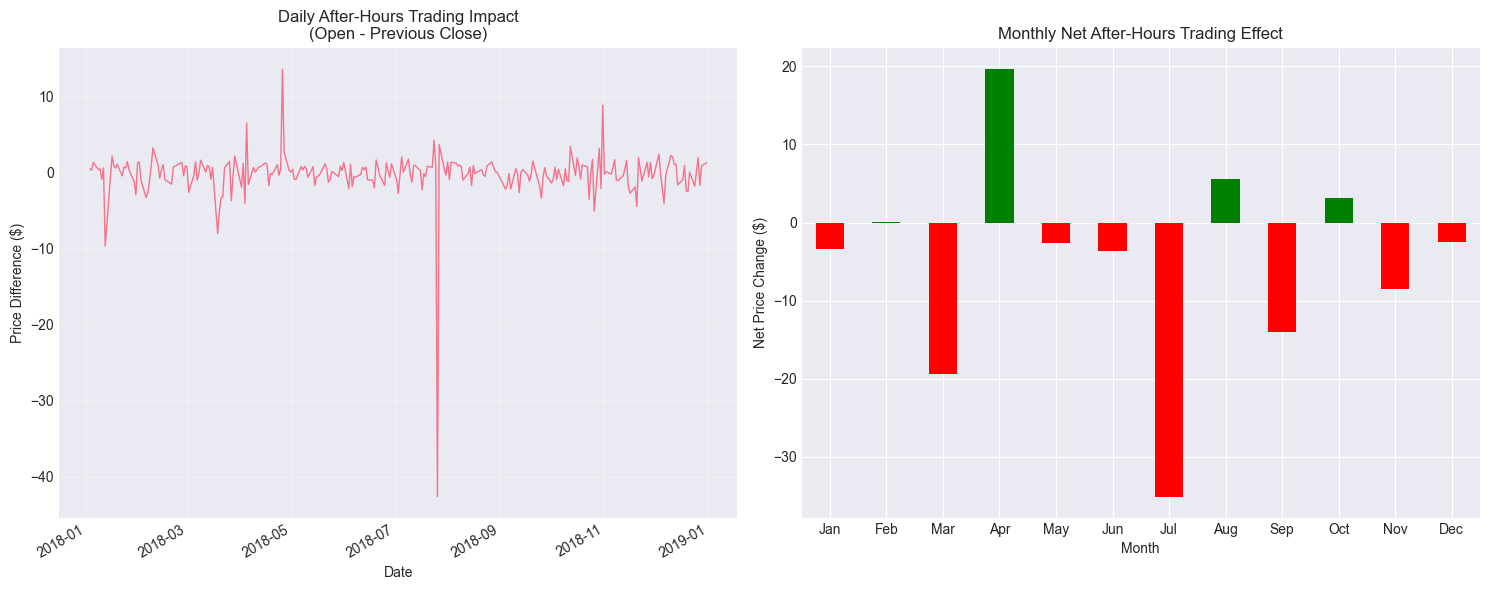

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

daily_diff = fb_df['open'] - fb_df['close'].shift(1)
daily_diff.plot(ax=ax1, linewidth=1)
ax1.set_title('Daily After-Hours Trading Impact\n(Open - Previous Close)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price Difference ($)')
ax1.grid(True, alpha=0.3)

monthly_effect = daily_diff.resample('ME').sum()

colors = ['green' if val >= 0 else 'red' for val in monthly_effect.values]
monthly_effect.plot(kind='bar', ax=ax2, color=colors)
ax2.set_title('Monthly Net After-Hours Trading Effect')
ax2.set_xlabel('Month')
ax2.set_ylabel('Net Price Change ($)')

month_labels = [date.strftime('%b') for date in monthly_effect.index]
ax2.set_xticklabels(month_labels, rotation=0)

plt.tight_layout()
plt.show()

In [15]:
print("\nSummary Statistics:")
print(f"Average daily open-to-close change: ${fb_df['open_to_close'].mean():.2f}")
print(f"Average weekly range: ${weekly_diff.mean():.2f}")
print(f"Total after-hours effect for the year: ${monthly_effect.sum():.2f}")


Summary Statistics:
Average daily open-to-close change: $0.06
Average weekly range: $11.01
Total after-hours effect for the year: $-60.77


In [16]:
print(f"\nBest month for after-hours trading: {monthly_effect.idxmax().strftime('%B')} (${monthly_effect.max():.2f})")
print(f"Worst month for after-hours trading: {monthly_effect.idxmin().strftime('%B')} (${monthly_effect.min():.2f})")


Best month for after-hours trading: April ($19.62)
Worst month for after-hours trading: July ($-35.07)


### Conclusion

In this data analysis activity I applied pandas and matplotlib techniques to uncover patterns from Facebook stock data and global earthquake records. Using rolling windows I calculated the 20 day minimum closing price to identify support levels and volatility trends throughout 2018. I created histograms with KDE overlays to analyze the distribution of daily price changes and used box plots to compare earthquake magnitude types across Indonesia. By resampling daily stock data into weekly ranges and monthly aggregates I transformed noisy fluctuations into clearer trend indicators. This activity demonstrated how combining data manipulation with visualizations can transform raw CSV files into actionable insights that would be impossible to see in spreadsheets alone.

# End